In [2]:
import sys
from pathlib import Path

import torch
import pyro
import pandas as pd
import seaborn as sns
import pyro.distributions as dist
import pyro.ops.stats as stats

rootDir = Path().resolve().parents[0]
sys.path.append(str(rootDir))

from rethinking import MAP, precis

/Users/trevorwilliams/github/SRBayesianPyro/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chapter begins with vampire testing example where you use Bayes Theorem to calculate the probability of being a vampire given a positive test:

$$ \text{Pr}(\text{vampire|positive}) = \frac{\text{Pr(positive|vampire)Pr(vampire)}}{\text{Pr(positive)}} $$

Where $ \text{Pr(positive)} $ is the average probability of a positive test result:

$$ \text{Pr(Positive)} = \text{Pr(positive|vampire)Pr(vampire)} + \text{Pr(positive|mortal)}(1-\text{Pr(vampire)}) $$

In [ ]:
# Code 3.1

Pr_Positive_Vampire = 0.95
Pr_Positive_Mortal = 0.01
Pr_Vampire = 0.001
Pr_Positive = Pr_Positive_Vampire * Pr_Vampire + Pr_Positive_Mortal * (1 - Pr_Vampire)
Pr_Vampire_Positive = Pr_Positive_Vampire*Pr_Vampire / Pr_Positive
Pr_Vampire_Positive


0.08683729433272395

The author states he doesn't like these examples because:

 1. There is nothing uniquely Bayesian about them. Bayesian inference is a broad view of probability not just using Bayes' Theorem
 2. These examples make Bayesian inference seem harder than they actually are

Can just as easily make it more intuitive by switching probabilities to counts:
 1. In a population of 100,000 people, 100 of them are vampires
 2. Of the 100 who are vampires, 95 of them will test positive for vampirism
 3. Of the 99,900 mortals, 999 of them will test positive

So:

$$ \text{Pr(vampire|positive)} = \frac{95}{1094} = 0.087 $$

Using counts is called the *frequency format* or *natural frequencies*. This chapter exploits this format (which is generally easier to understand) by taking probability distributions and sampling from them to produce counts. Specifically taking samples from the posterior distribution

## 3.1 Sampling from a grid-approximate posterior

Before sampling from the posterior, we first create one using the globe tossing example



In [25]:
# Code 3.2

p_grid = torch.linspace(start=0, end=1, steps=1000)
prob_p = torch.tensor(1.).repeat(1000)
prob_data = dist.Binomial(total_count=9, probs=p_grid).log_prob(torch.tensor(6.)).exp()
posterior = prob_data * prob_p
posterior = posterior / sum(posterior)


Analogy -> assume that our posterior is a bucket full of parameter values that exist in proportion to their posterior probability. Sampling is like taking a scoop from the bucket - the samples in the scoop should be in the same proportion they are in the bucket.

In [26]:
# Code 3.3
samples = dist.Empirical(p_grid, posterior.log()).sample(torch.Size([int(1e4)]))

[Text(0.5, 0, 'sample number'), Text(0, 0.5, 'proportion water (p)')]

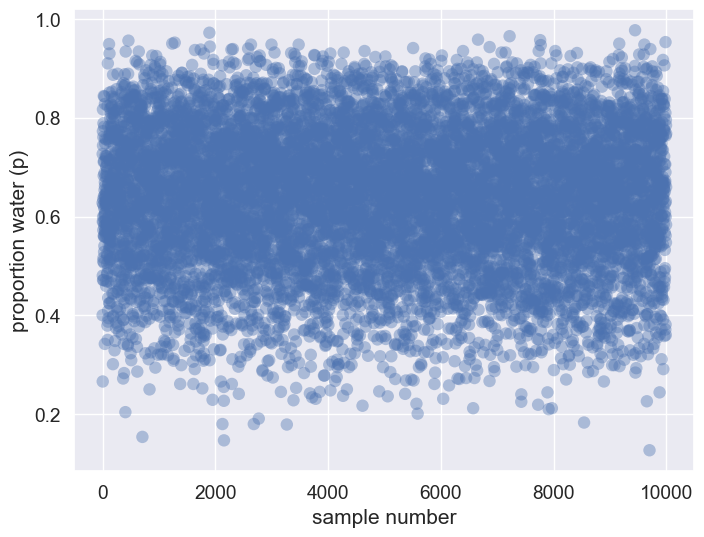

In [9]:
# code 3.4 
ax = sns.scatterplot(x=range(len(samples)), y=samples, s=80, alpha=0.4, edgecolor="none")
ax.set(xlabel="sample number", ylabel="proportion water (p)")

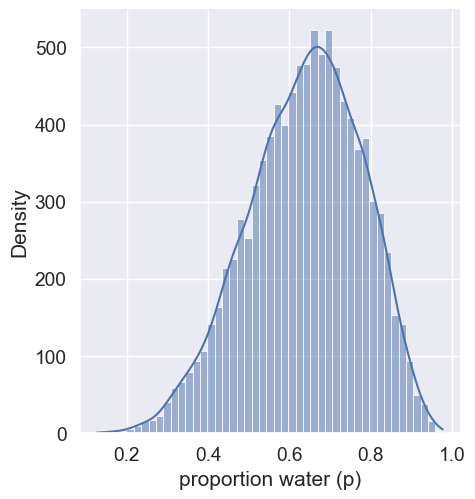

In [16]:
# code 3.5

ax = sns.displot(samples, kde=True)
ax.set(xlabel='proportion water (p)', ylabel='Density')


## 3.2 Sampling to summarize

Common questions regarding summarizing the posterior distribution:

 * How much posterior probability lies below some parameter value?
 * How much posterior probability lies between two parameter values?
 * Which paramater value markes the lower 5% of the posterior probability?
 * Which range of parameter values contains 90% of the posterior probability?
 * Which parameter value has highest posterior probability?

### 3.2.1 Intervals of defined boundaries

To find the posterior probability that the proportion of water is less than 0.5 using the grid-approximate posterior, just add up all of the probabilities where the corresponding parameter value is less than 0.5

In [18]:
(posterior[p_grid < 0.5]).sum()

tensor(0.1719)

This indicates that 17% of the posterior probability is below 0.5. But often grid-approximation is infeasible so this method won't work all of the time. 

To perform the same calculation using samples from the posterior, take all the values that are less than 0.5 and divide by the total number of samples


In [20]:
(samples < 0.5).sum().float() / len(samples)

tensor(0.1688)

Using the same approach you can ask how much of the posterior probability lies between 0.5 and 0.75:

In [24]:
((samples > 0.5) & (samples < 0.75)).sum().float() / len(samples)

tensor(0.6020)

### 3.2.2 Intervals of defined mass

Journals often report intervals of defined mass, usually known as **CONFIDENCE INTERVALS**. In Bayesian statistics, an interval of posterior probability is called a **CREDIBLE INTERVAL** or **COMPATIBILITY INTERVAL**. This interval indicates a range of parameter values (two values) that between them contain a specified amount of posterior probability (a probability mass). For example to find the lower 80% of posterior probability do: 

In [25]:
stats.quantile(samples, 0.8)

tensor(0.7638)

Thus the lower 80% of posterior probability lies between the parameter values 0 and 0.76. To find the middle 80% interval:

In [26]:
stats.quantile(samples, [0.1, 0.9])

tensor([0.4494, 0.8158])

Intervals like this that assign equal probability mass to each tail are common in scientific literature and can be called **PERCENTILE INTERVALS** (PI). They can do a good job of communicatirng the shape of a distribution as long as it isn't too asymmetrical. But in terms of supporting inferences about which parameters are consistent with the data, they are not perfect. For example:

In [ ]:
# code 3.11
p_grid = torch.linspace(start=0, end=1, steps=1000)
prior = torch.ones(1000)
likelihood = dist.Binomial(total_count=3, probs=p_grid).log_prob(torch.tensor(3.)).exp()
posterior = likelihood * prior
posterior = posterior / posterior.sum()
samples = dist.Empirical(p_grid, posterior.log()).sample(torch.Size([int(1e4)]))

In [ ]:
# code 3.12
stats.pi(samples, prob=0.5)

tensor([0.7037, 0.9309])

This interval includes the cetnral 50% probability but excludes the most probabile parameter values near $p = 1$. So the percentile interval can be misleading as to the shape of the distribution. Instead you can compute the 50% **HIGHEST POSTERIOR DENSITY INTERVAL** (HPDI). This is the narrowest interval containing the specified probability mass. 

In [32]:
stats.hpdi(samples, prob=0.5)

tensor([0.8398, 1.0000])

In practice, both the PI and HPDI will be very similar. 

HPDI has some disadvantages:
 * More computationally intensive than PI
 * Suffers from greater *simulation variance*
 * Harder to understand (kind of)

Remember, the entire posterior distribution is the Bayesian "Estimate". Intervals are just helpful for summarizing it. If the intervals give different inferences, its best to display the entire posterior.

### 3.2.3 Point estimates

Common point estimates that are used to describe the posterior are the *maximum a posteriori* (MAP) or mode, mean, and median. Though these can give different values/inferences. To find the grid-approximated MAP use

In [33]:
p_grid[posterior.argmax()]

tensor(1.)

To find the MAP using samples do:

In [34]:
adj = 0.01
silverman_factor = (0.75 * samples.size(0)) ** (-0.2)
bandwidth = adj * silverman_factor * samples.std()
x = torch.linspace(samples.min(), samples.max(), 1000)
y = dist.Normal(samples, bandwidth).log_prob(x.unsqueeze(-1)).logsumexp(-1).exp()
x[y.argmax()]

tensor(0.9039)

To find the mean and median:

In [35]:
print(samples.mean())
print(samples.median())

tensor(0.7998)
tensor(0.8398)


A more principled way to produce a point estimate is to choose a **LOSS FUNCTION**. A loss function is a rule that tells you the cost associated with using any particular point estimate. One key result though is that different loss functions imply different point estimates.

Calculating expected loss for any given decision means using the posterior to average over our uncertainty in the true value. Say we choose $p = 0.5$ as our decision and the loss function is $|d - p|$. We can calculate the expected loss as:

In [36]:
# code 3.17

(posterior * (0.5-p_grid).abs()).sum()

tensor(0.3129)

Now calculating the weighted average loss for every value of the posterior

In [37]:
loss = (posterior * (p_grid.unsqueeze(1) - p_grid).abs()).sum(1)

Now to find the parameter that minimizes the loss:

In [38]:
# code 3.19
p_grid[loss.argmin()]

tensor(0.8408)

Which corresponds to the posterior median in this case. All these calculations point to the fact that to decide upon a *point estimate* to summarize the posterior distribution, you need to pick a loss function. And different loss functions nominate different estimates. 

### 3.3 Sampling to simulate prediction

Another common job for samples is to ease **SIMULATION** of the model's implied observations. This is useful for at least four reasons:
 1. Model design - we can also sample from the prior to see what the model expects, before the data arrive. This allows us to understand the implications of the prior.
 2. Model checking - After Bayesian updating, it is worth simulating implied observations to check both whether the fit worked correctly and to investigate model behavior. 
 3. Software validation - To see if the model fitting software works we can simulate observations under a known model and then attempt to recover teh values of the parameters the data were simulated under.
 4. Research design - narrow sense = power analysis, broad sense can see if the research design will be effective
 5. Forecasting - Estimates can be used to simulate new predictions for new cases and future observations. Useful for prediction and model criticism

#### 3.3.1 Dummy data

Will continue working with the globe tossing model. Remember the assumptions:
 * A fixed true proportion $p$ of water exists - target of inference
 * Tossing the globe produces observations of "water" and "land" that appear in proportion to $p$ and $1-p$ respectively

These assumptions allow us to infer the plausibility of each value of $p$ after observation. They also allow us to simulate the observations that the model implies - i.e. likelihood functions work both ways. Given only the parameters, the likelihood defines a distribution of possible observations that we can sample from to simulate observation.

What this means is that Bayesian models are always *generative*. We call such simulated data **DUMMY DATA**. For the globe tossing model, the dummy data arises from a binomial likelihood:

$$ \text{Pr}(W|N,p) = \frac{N!}{W!(N-W!)}p^W(1-p)^{N-W}$$

Where $W$ is an aobserved cound of "water" and $N$ is the number of tosses. Suppose $N=2$ then there are only three possible observations: 0 water, 1 water, 2 water. You can quickly calculate the probability of each for any given value of $p$. With $p=0.7$:

In [3]:
# code 3.20

dist.Binomial(total_count=2, probs=0.7).log_prob(torch.arange(3.)).exp()

tensor([0.0900, 0.4200, 0.4900])

Above used the exact likelihood to compute the distribution of implied observations. You can also generate it by sampling from the distribution described above. Using pyro you can generate a single dummy sample by:

In [5]:
# code 3.21 

dist.Binomial(total_count=2, probs=0.7).sample().long()

tensor(0)

To generate more than one simulation at a time:

In [6]:
# code 3.22

dist.Binomial(total_count=2, probs=0.7).sample(torch.Size([10])).long()

tensor([1, 1, 2, 1, 2, 2, 2, 1, 2, 2])

Let's generate 100000 dummy observations, just to veryify that each value (0, 1, or 2) appears in proportion to its likelihood

In [8]:
# code 3.23

dummy_w = dist.Binomial(total_count=2, probs=0.7).sample(torch.Size([int(1e5)])).long()
dummy_w.long().bincount().float() / 1e5

tensor([0.0913, 0.4184, 0.4904])

Now sampling the same sample size in the examples before, 9:

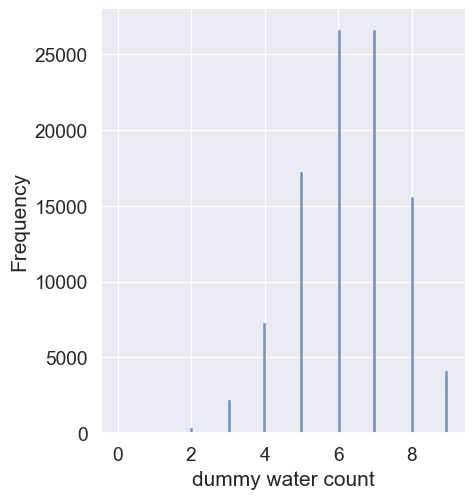

In [22]:
# code 3.24

dummy_w = dist.Binomial(total_count=9, probs=0.7).sample(torch.Size([int(1e5)])).long()
ax = sns.displot(dummy_w)
ax.set(xlabel="dummy water count", ylabel="Frequency")

Notice:
 * most of the time the expected observation does not contain water in its true proportion, 0.7
 * There is a one-to-many relationship between data and data-generating processes

### 3.3.2 Model checking

**MODEL CHECKING** means:
 1. ensuring the model fitting worked correctly
 2. evaluating the adequacy of a model for some purpose

#### 3.3.2.1 Did the software work?

Simplest case - check if the software worked by checking correspondence between implied predictions and the data used to fit the model (aka *retrodictions*)

Can't expect there to be an exact match. But if no correspondance seen then that suggests something is wrong.

#### 3.3.2.2 Is the model adequate?

After checking the software worked correctly, it is useful to look for aspects of the data that are not well described by the model's expectations.

Goal: to assess exactly how the model fails to describe the data, as a path towards model comprehension, revision, and improvement. NOT to test if the model's assumptions are true (all models are false)

Imperfect prediction (retrodiction) is not a bad thing. 

Want to combine sampling of simulated observations with sampling parameters from the posterior distribution across the whole posterior distribution. 

For globe tossing model, implied predictions of the model are uncertain in two ways:
 1. Observation uncertainty - there is uncertainty in the predicted observations, because even if you know $p$ with certainty, you won't know the next globe toss with certainty (unless $p$ = 0 or $p$ = 1)
 2. There is uncertainty about $p$. The posterior distribution over $p$ embodies this uncertainty. The uncertainty in $p$ will interact with the sampling variation, when we try to assess what the model tells us aabout outcomes. 

 We need to *propagate* the parameter uncertainty as we evaluate the implied predictions. To do this we just need to average over the posterior density for $p$, while computing the predictions. e.g. compute the sampling distribution of outcomes at each value of $p$, then average all of these prediction distributions together, using the posterior probabilities of each value $p$ = **POSTERIOR PREDICTIVE DISTRIBUTION**

 The posterior predictive distribution is for predictions but it incorporates all of the uncertainty embodied in th posterior distribution for the parameter $p$. If you just use a single parameter value you get overconfident predictions that will lead you to believe the model is more consistent with the data than it really is. (e.g. using just 0.6 will make the peaks taller around 6 "water" observations. The posterior predictive distributions distributes the uncertaintity across possible observations).

 How to do this in python? To simulate predicted observations for a single value of $p$ do:

In [23]:
# Code 3.25

w = dist.Binomial(total_count=9, probs=0.6).sample(torch.Size([int(1e4)]))
w

tensor([6., 4., 5.,  ..., 3., 4., 3.])

To propogate parameter uncertainty into the predictions, replace the single parameter value with samples from the posterior

In [37]:
w.flatten()

tensor([6., 4., 3.,  ..., 3., 0., 8.])

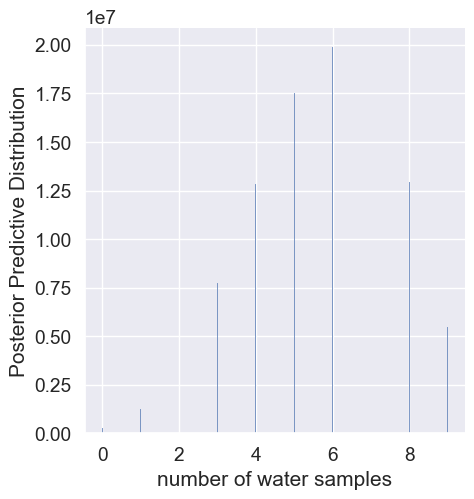

In [39]:
w = dist.Binomial(total_count=9, probs=samples).sample(torch.Size([int(1e4)]))
ax = sns.displot(w.flatten())
ax.set(xlabel="number of water samples", ylabel="Posterior Predictive Distribution")


Since the sampled values appear in proportion to their posterior probabilities, the resulting simulated observations are averaged over the posterior. You can then manipulate these simulated observations just like you manipulate samples from the posterior - you can compute intervals and point statistics using the same procedures.

In this case the simulated model predictions are consistent with the data (with 6 having the highest frequency). However, you can evaluate your model in other ways. The book provides examples to look at the correlation of water to land by investigating if the longest run length and the number of switches is consistent with the data. The number of switches is not consistent with the data, suggesting a lack of independence between tosses of the globe. 

Doesn't necessarily mean the model is bad, in some sense the model will always be mis-specified.